[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

### Lecture 6 Time-series
- AR(1) model
- filtering - trend

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.tsa.stattools as stattools

## AR(1) model

Fit the AR(1) model

$$ X_t = \phi X_{t-1} + W_t + k $$

where $W_t$ is white noise. Let's set $k = 0$:

$$ X_t = \phi X_{t-1} + W_t $$

- read data and organize the data to give a date column

In [2]:
df = pd.read_csv("./noaa_roni.csv")
seasons = ["DJF","JFM","FMA","MAM","AMJ","MJJ","JJA","JAS","ASO","SON","OND","NDJ"]
season_to_month = {s: i+1 for i, s in enumerate(seasons)}
df["month_idx"] = df["Season"].map(season_to_month)
df["date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["month_idx"].astype(str) + "-01")

df

,Year,Season,RONI,month_idx,date
0,1950,DJF,-1.5,1,1950-01-01
1,1950,JFM,-1.3,2,1950-02-01
2,1950,FMA,-1.1,3,1950-03-01
3,1950,MAM,-1.1,4,1950-04-01
4,1950,AMJ,-1.0,5,1950-05-01
...,...,...,...,...,...
911,2025,NDJ,-1.0,12,2025-12-01
912,2026,DJF,-0.9,1,2026-01-01
913,2026,JFM,-0.7,2,2026-02-01
914,2026,FMA,-0.4,3,2026-03-01


- calculate a lag-1 autocorrelation

In [3]:
roni = df["RONI"].values
rho   = stattools.acf(roni, nlags=1, adjusted=False)

- calculate sigmaW for lage 1

In [4]:
phi_hat = rho[1]
x_hat = phi_hat * roni[:-1]
residuals = roni[1:] - x_hat
sigma_W_hat = residuals.std()
print(sigma_W_hat)

0.2095252942800356


 ### build an AR(1) ENSO model with lead time from 1 to 12 months

- give a initial date and set X0, lead times

In [5]:
idx = np.where(df['date'] == '1997-07-01')[0][0]
x0 = roni[idx]
forecast_horizon = 12 ## month
t_ahead = np.arange(0, forecast_horizon + 1) ### time index

- the general distribuiton of $x_t$

$$
p(x_t \mid x_0) \sim N\left(\phi^t x_0,\ \sigma_W^2 \frac{1-\phi^{2t}}{1-\phi}\right)
$$

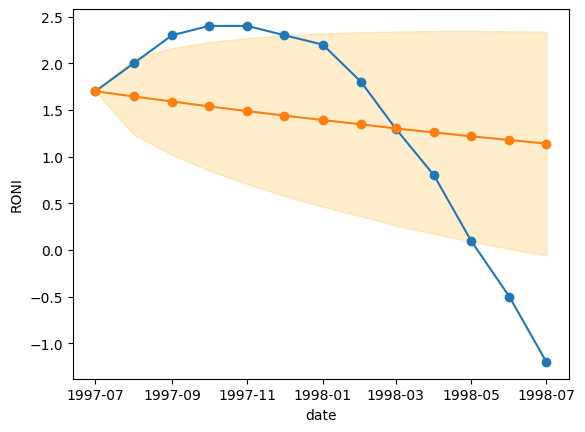

In [6]:
x_hat_mean = phi_hat**t_ahead * x0
x_hat_var = sigma_W_hat**2 * (1 - phi_hat**(2*t_ahead)) / (1 - phi_hat**2)
x_hat_var[0] = 0
x_hat_std = np.sqrt(x_hat_var)


plt.plot(df['date'][idx:idx+forecast_horizon+1],roni[idx:idx+forecast_horizon+1],'o-')
plt.plot(df['date'][idx:idx+forecast_horizon+1],x_hat_mean,'o-')
plt.fill_between(df['date'][idx:idx+forecast_horizon+1],x_hat_mean - 1.96*x_hat_std, x_hat_mean + 1.96*x_hat_std,color='orange', alpha=0.2, label='95% forecast interval')
plt.xlabel('date')
plt.ylabel('RONI')
plt.savefig('ENSO_AR1_exp3.png')

-try other dates

- let's plot theoretical (model) and observed (data) ACF

In [7]:
max_lag = 12
rho = stattools.acf(roni, nlags=max_lag, adjusted=False)[1:] ### from data



In [8]:
acf_model = phi_hat ** np.arange(1,max_lag+1)   # theoretical ACF of an AR(1): rho_tau = phi^tau

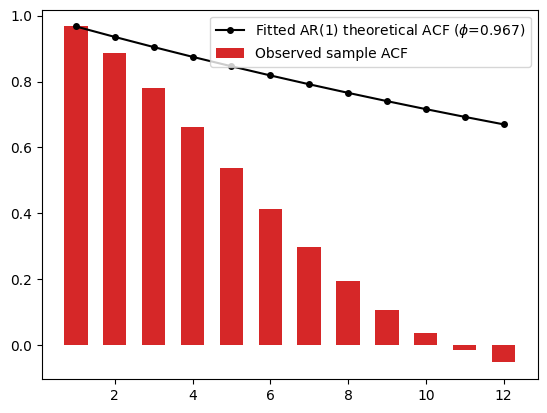

In [9]:
plt.bar(np.arange(1,max_lag+1), rho, color='tab:red', width=0.6, label='Observed sample ACF')
plt.plot(np.arange(1,max_lag+1), acf_model, color='black', marker='o', ms=4, lw=1.5,
         label=f'Fitted AR(1) theoretical ACF ($\\phi$={phi_hat:.3f})')
plt.legend()

-- hands on --

In [11]:
df = pd.read_csv("./nyc_tmax_anomaly_2000_2005.csv", parse_dates=["DATE"])
df

,DATE,TMAX,clim,anomaly
0,2000-01-01,50,41.080889,8.919111
1,2000-01-02,60,40.915590,19.084410
2,2000-01-03,64,40.757790,23.242210
3,2000-01-04,60,40.607635,19.392365
4,2000-01-05,47,40.465266,6.534734
...,...,...,...,...
2187,2005-12-27,43,42.014531,0.985469
2188,2005-12-28,50,41.814038,8.185962
2189,2005-12-29,51,41.620268,9.379732
2190,2005-12-30,47,41.433382,5.566618


In [13]:
max_lag = 1
x = df.anomaly.values
rho   = stattools.acf(x, nlags=max_lag, adjusted=False)[1]

x_hat = rho * x[:-1]
residuals = x[1:] - x_hat
sigma_w_hat = residuals.std()

In [14]:
# 3. Forecast: start Jan 1, lead time = 10 days

idx0 = np.where(df["DATE"] == "2000-01-01")[0][0]
x0 = x[idx0]

forecast_horizon = 10
t_ahead = np.arange(0, forecast_horizon + 1)

x_hat_mean = (rho**t_ahead) * x0
x_hat_var = sigma_w_hat**2 * (1 - phi_hat**(2*t_ahead)) / (1 - phi_hat**2)

In [15]:
x_hat_var[0] = 0
x_hat_std = np.sqrt(x_hat_var)

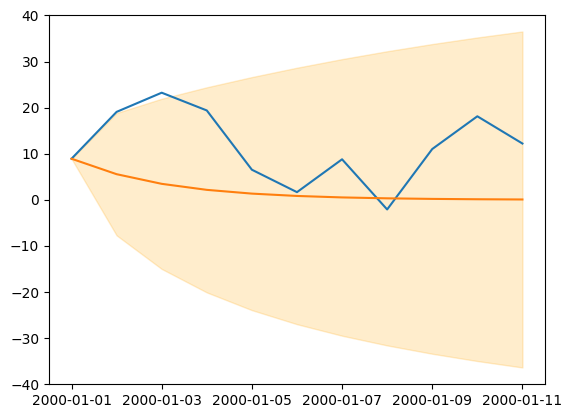

In [16]:
plt.plot(df["DATE"][idx0:idx0+forecast_horizon+1],x[idx0:idx0+forecast_horizon+1])
plt.plot(df["DATE"][idx0:idx0+forecast_horizon+1],x_hat_mean)
plt.fill_between(df["DATE"][idx0:idx0+forecast_horizon+1], x_hat_mean - 1.96*x_hat_std, x_hat_mean + 1.96*x_hat_std,
                  color='orange', alpha=0.2, label='95% forecast interval')